#### EDA (Exploratory Data Analysis) is the process of examining, cleaning, summarizing, and visualizing data to understand its structure, identify patterns, detect outliers, handle missing values, and gain insights before further analysis or modeling.

##### **Simple Real-Life Analogy**

*Imagine you're buying a used car.*
*Before purchasing, you inspect:*

*Engine condition*
*Mileage*
*Service history*
*Tire condition*
*Accident records*

*This inspection is like EDA.*

*Before using data, you inspect it to understand its quality and characteristics.*

In [25]:

##In a Data Analyst Project

## Typical EDA workflow:

## df.head()
## df.info()
## df.describe()
## df.isnull().sum()
## df.duplicated().sum()

## sns.histplot(...)
## sns.boxplot(...)
## sns.countplot(...)
## sns.heatmap(...)


In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
df=pd.read_csv("Diwali Sales Data.csv", encoding='unicode_escape')

In [7]:
df.shape

(11251, 15)

In [8]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [13]:
df.drop(['Status','unnamed1'], axis=1,inplace=True)

In [14]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [15]:
df['Amount']=df['Amount'].fillna(df['Amount'].mean())

In [16]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [17]:
df['Amount']=df['Amount'].astype(int)

In [18]:
df['Amount'].dtype

dtype('int64')

In [20]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [21]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11251.000000
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.609901
std,1.716125e+03,12.754122,0.493632,1.115047,5219.569169
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.500000
50%,1.003065e+06,33.000000,0.000000,2.000000,8110.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12671.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


### Exploratory Data Analysis

##### **Gender**

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\2385279448.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Gender', data=df, palette='Blues')


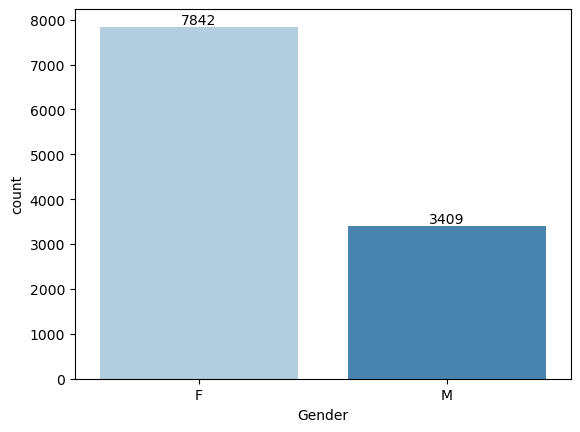

In [28]:
ax=sns.countplot(x='Gender', data=df, palette='Blues')
for bars in ax.containers:
    ax.bar_label(bars)

In [32]:
df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

,Gender,Amount
0,F,74430383
1,M,31932182


C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\834134485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Amount', data=sales_gen, palette="Reds")


<Axes: xlabel='Gender', ylabel='Amount'>

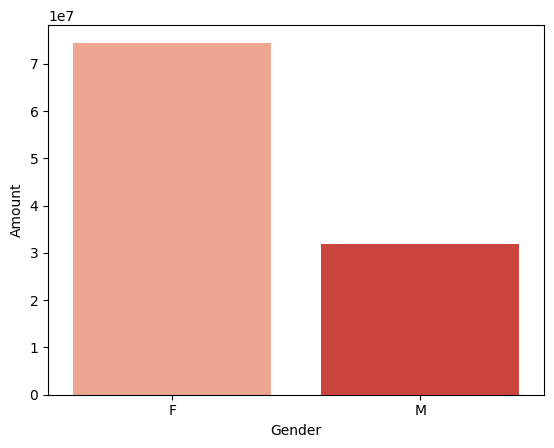

In [41]:
sales_gen=df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Gender', y='Amount', data=sales_gen, palette="Reds")

# When you write:
# sns.barplot(x='Gender', y='Amount', data=df)
# Seaborn does:
# df.groupby('Gender')['Amount'].mean()

# Because sns.barplot() uses the mean as the default estimator. If I want total sales, total profit, or total quantity, I first aggregate the data using groupby() and then pass the summarized dataframe to barplot()."

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\2934494875.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Amount', data=df, estimator=sum, palette='Reds')


<Axes: xlabel='Gender', ylabel='Amount'>

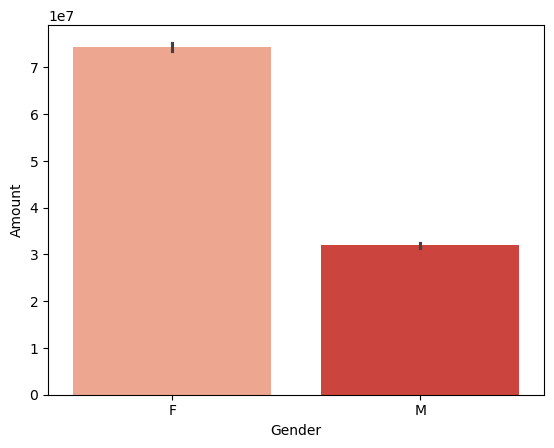

In [40]:
sns.barplot(x='Gender', y='Amount', data=df, estimator=sum, palette='Reds')

 *From the above bargraph we can see that most of the buyers are female and even purcshasing power of female is more*

##### **Age**

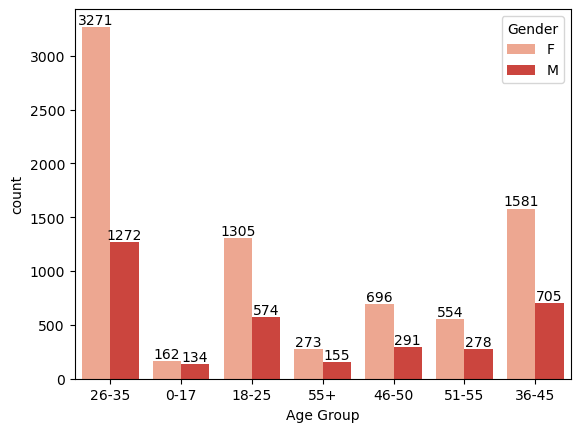

In [48]:
ax= sns.countplot(x='Age Group', data=df, hue='Gender', palette='Reds')
for bar in ax.containers:
    ax.bar_label(bar)

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\2098628619.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Age Group', y='Amount', data=df, estimator=sum, palette='Reds')


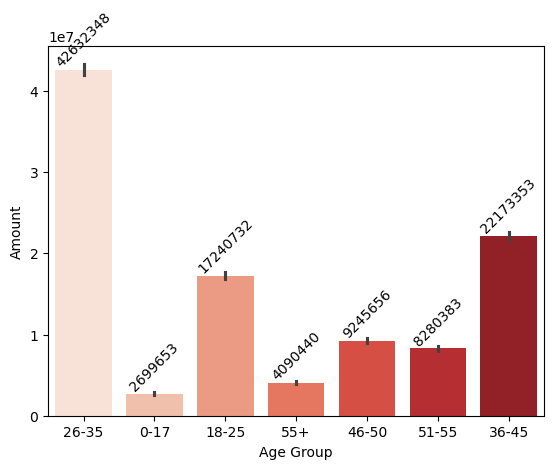

In [51]:
ax=sns.barplot(x='Age Group', y='Amount', data=df, estimator=sum, palette='Reds')
for bar in ax.containers:
    ax.bar_label(bar,fmt='%.0f', rotation=45)


 *From the above graph we can see that most of the buyers are from Age Group 26-35 females*

##### **State**

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\693229214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Orders', x='State', data=df, estimator=sum, palette='Reds')


<Axes: xlabel='State', ylabel='Orders'>

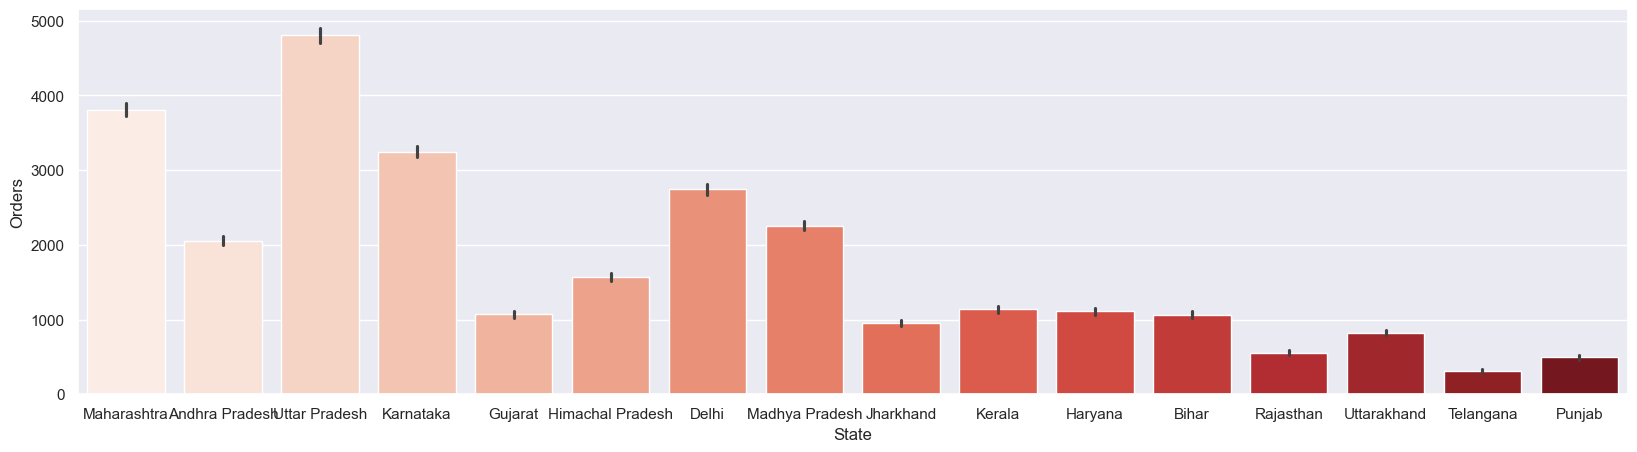

In [62]:
#total numbers of orders from top 10 States
sns.set(rc={'figure.figsize':(20,5)})

sns.barplot(y='Orders', x='State', data=df, estimator=sum, palette='Reds')

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\2547298078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Amount', x='State', data=df, estimator=sum, palette='Reds')


<Axes: xlabel='State', ylabel='Amount'>

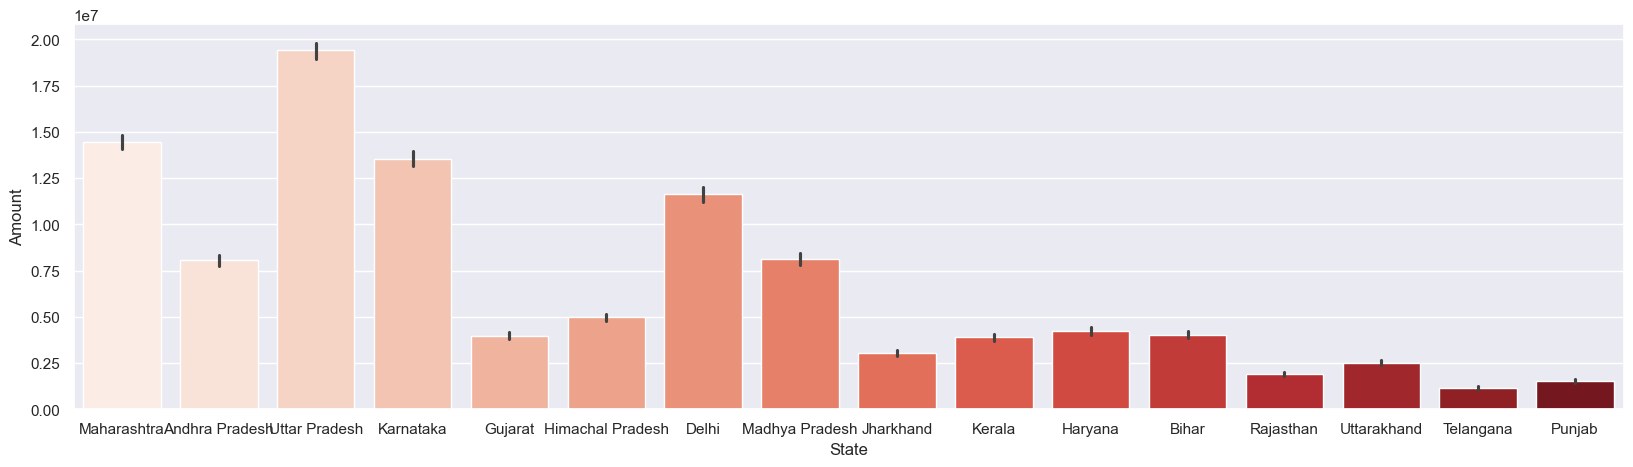

In [ ]:
#total Amount spend by States
sns.set(rc={'figure.figsize':(20,5)})

sns.barplot(y='Amount', x='State', data=df, estimator=sum, palette='Reds')

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*

##### **Marital Status**

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\1973660806.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Marital_Status', data=df, palette='Reds')


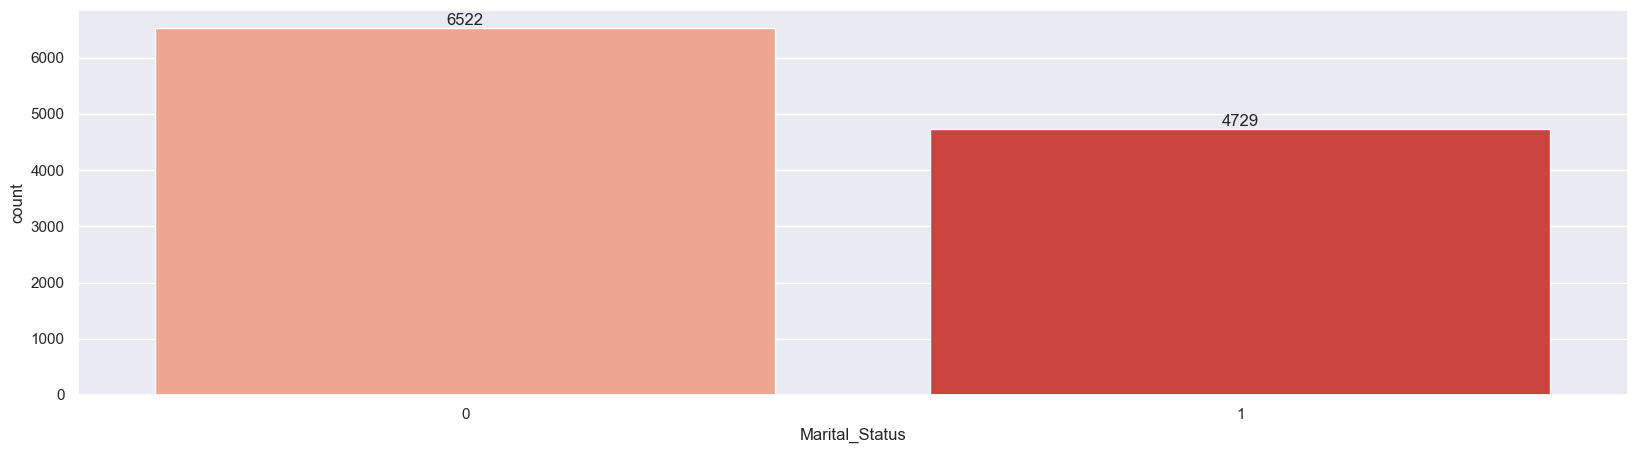

In [66]:
ax=sns.countplot(x='Marital_Status', data=df, palette='Reds')
for bar in ax.containers:
    ax.bar_label(bar)

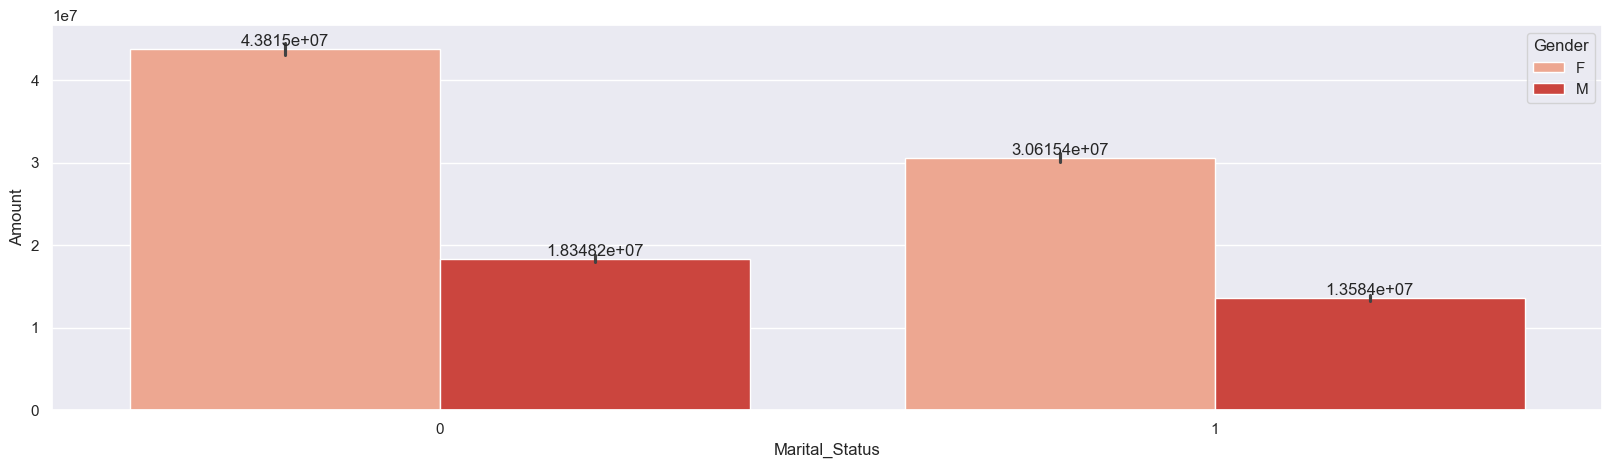

In [69]:
ax=sns.barplot(x='Marital_Status', y='Amount', data=df, estimator=sum, palette='Reds', hue='Gender')
for bar in ax.containers:
    ax.bar_label(bar)

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

##### **Occupation**

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\1862843717.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Occupation', data=df,  palette='Reds')


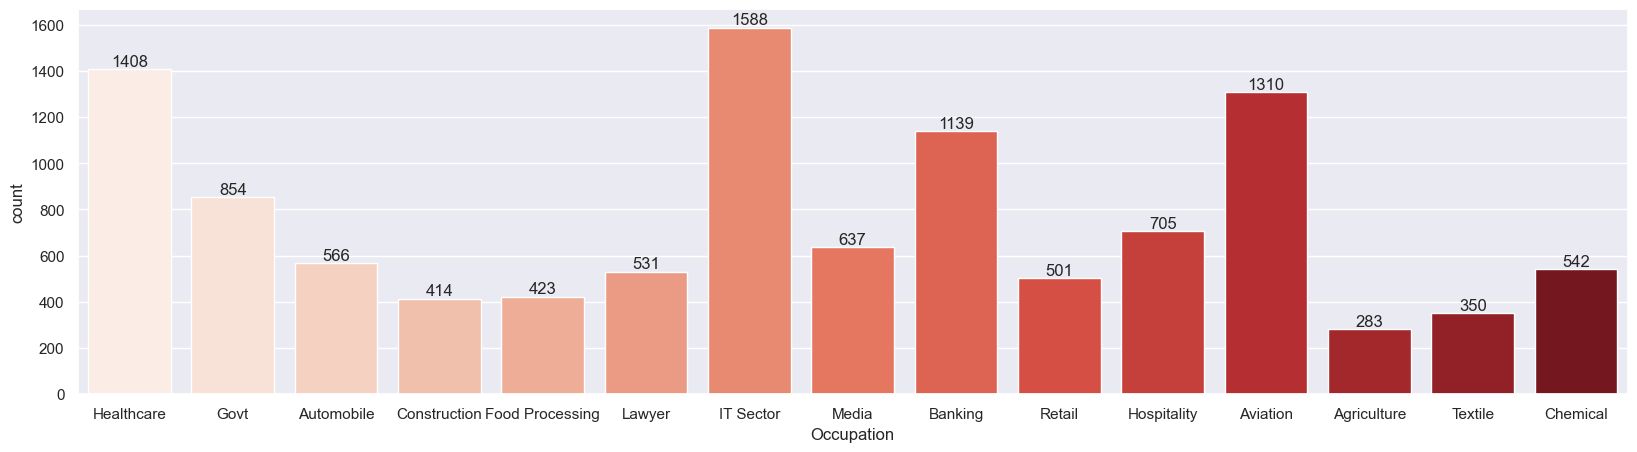

In [73]:
ax=sns.countplot(x='Occupation', data=df,  palette='Reds')
for bar in ax.containers:
    ax.bar_label(bar)

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\1997685139.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount', palette='Reds')


<Axes: xlabel='Occupation', ylabel='Amount'>

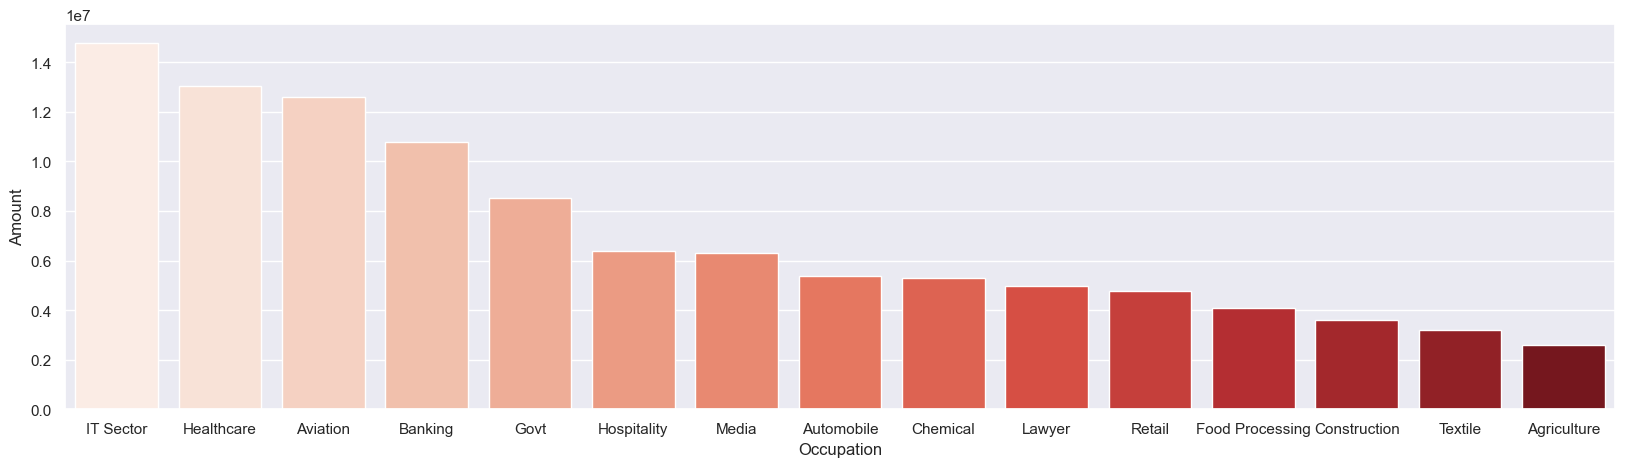

In [80]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount', palette='Reds')


*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

##### **Product Category**

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\3782640284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = df, x = 'Product_Category',palette='Reds')


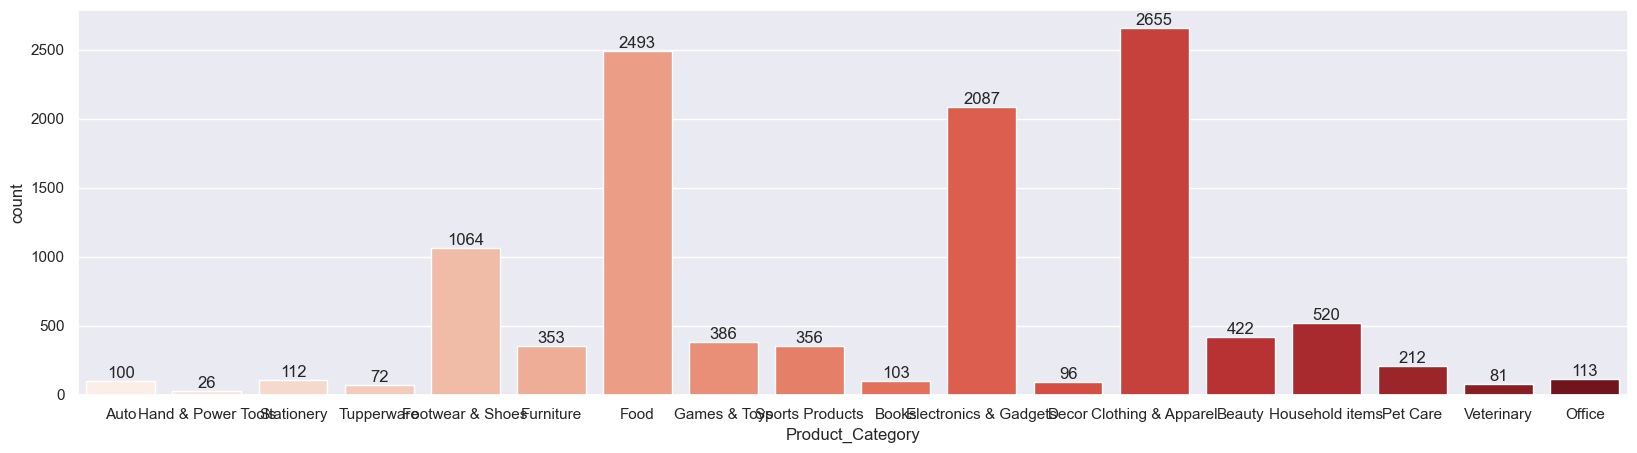

In [84]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category',palette='Reds')

for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\2299560337.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount',palette='Reds')


<Axes: xlabel='Product_Category', ylabel='Amount'>

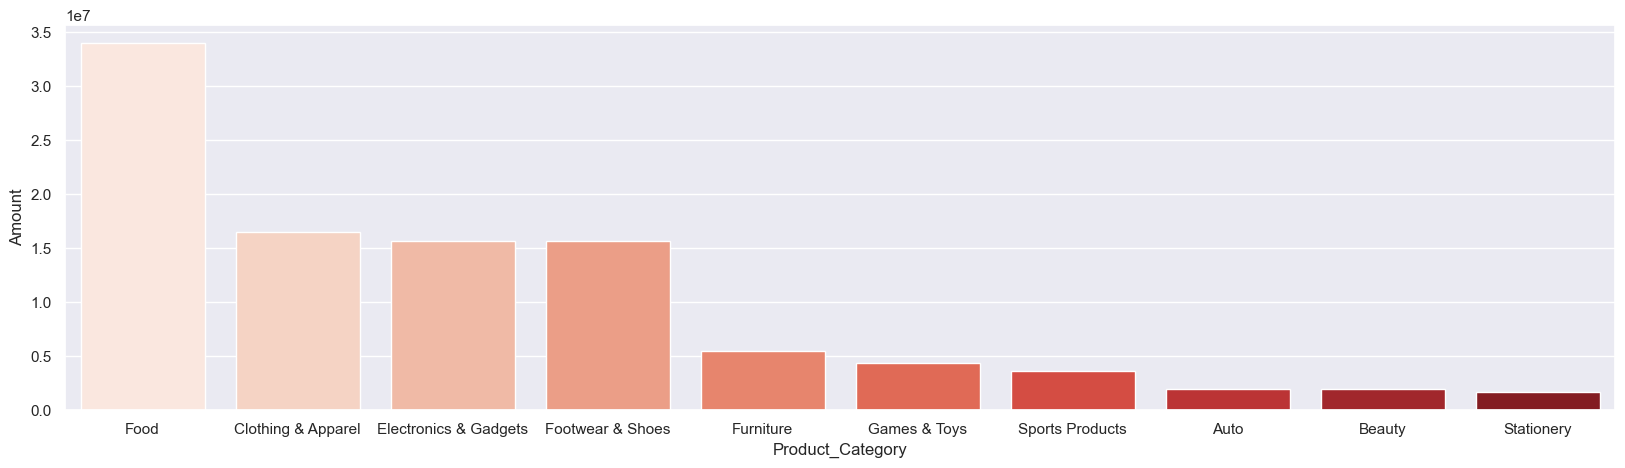

In [85]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount',palette='Reds')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

C:\Users\Riya Bhatt\AppData\Local\Temp\ipykernel_20236\3429348080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders',palette='Reds')


<Axes: xlabel='Product_ID', ylabel='Orders'>

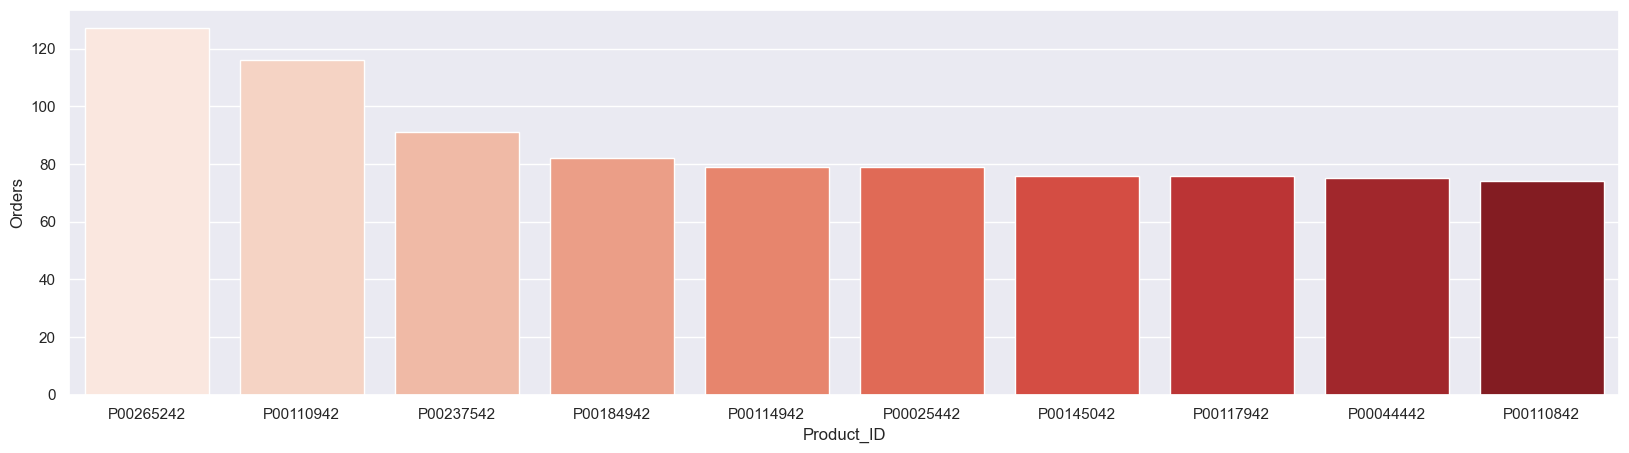

In [87]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders',palette='Reds')

#### **Conclusion**

*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*